# Clean raw data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import datetime

## Delist

In [ ]:
delist = pd.read_csv('/Users/mabel/Desktop/Paper Data/US Bankruptcy/Raw data/delisting14-24.csv')

In [ ]:
# Filter for bankruptcy delistings
bkpy = delist[delist['DelReasonType']=='BKPY'].copy()
# Convert DelistingDt to datetime and extract year
bkpy['DelistingDt'] = pd.to_datetime(bkpy['DelistingDt'], errors='coerce')
bkpy['DelistingDt_year']= bkpy['DelistingDt'].dt.year 
# Drop rows with invalid dates
bkpy = bkpy[(bkpy['DelistingDt_year']>=2019) & (bkpy['DelistingDt_year']<=2024)]

In [ ]:
link = pd.read_excel('/Users/mabel/Desktop/Paper Data/US Bankruptcy/Raw data/link table.xlsx')

In [ ]:
# Merge bkpy with link table on PERMNO and rename columns
merge_delist_link = pd.merge(bkpy, link, left_on='PERMNO', right_on='Historical CRSP PERMNO Link to COMPUSTAT Record', how='left')
merge_delist_link.rename(columns={'DelistingDt':'delist date','DelistingDt_year':'delist year','Global Company Key':'gvkey','Ticker Symbol':'ticker'}, inplace=True)
merge_delist_link

,PERMNO,delist date,DelDtPrc,DelDtPrcFlg,DelActionType,DelStatusType,DelReasonType,DelPaymentType,DelPERMNO,DelPERMCO,...,CIK Number,Standard Industry Classification Code,North American Industry Classification Code,Primary Link Marker,Security-level Identifier,Link Type Codd,Historical CRSP PERMNO Link to COMPUSTAT Record,Historical CRSP PERMCO Link to COMPUSTAT Record,First Effective Date of Link,Last Effective Date of Link
0,10180,2020-05-29,0.0900,TR,GDR,VCL,BKPY,PRCF,0,0,...,3116.0,2834.0,325412.0,P,01,LU,10180.0,9743.0,1988-04-08,2020-10-05
1,10656,2019-04-02,0.1345,TR,GDR,VCL,BKPY,PRCF,0,0,...,2034.0,5160.0,424690.0,P,01,LC,10656.0,37.0,1972-12-14,2019-10-02
2,12660,2020-06-29,0.5500,TR,GDR,VCL,BKPY,PRCF,0,0,...,1502034.0,5400.0,446191.0,P,01,LC,12660.0,53710.0,2011-04-01,2020-10-31
3,12792,2020-08-03,1.9000,TR,GDR,VCL,BKPY,PRCF,0,0,...,1512077.0,4899.0,517410.0,P,02,LC,12792.0,53773.0,2011-05-27,2021-03-31
4,12796,2024-11-15,1.0800,TR,GDR,VCL,BKPY,PRCF,0,0,...,1498710.0,4512.0,481111.0,P,01,LC,12796.0,53776.0,2011-05-31,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,91739,2019-06-27,0.0395,TR,GDR,VCL,BKPY,PRCF,0,0,...,1735828.0,1311.0,211120.0,P,01,LC,91739.0,51657.0,2007-01-12,2019-12-13
125,92400,2024-08-09,0.8438,TR,GDR,VCL,BKPY,PRCF,0,0,...,1396033.0,5211.0,444110.0,P,01,LC,92400.0,52839.0,2007-11-09,2024-08-09
126,93420,2020-10-09,0.1550,TR,GDR,VCL,BKPY,PRCF,0,0,...,1486159.0,1311.0,2111.0,N,01,LC,93420.0,53438.0,2020-11-20,2020-11-30
127,93420,2020-10-09,0.1550,TR,GDR,VCL,BKPY,PRCF,0,0,...,1486159.0,1311.0,2111.0,C,01,LC,93420.0,53438.0,2020-11-01,2020-11-19


In [ ]:
# del missing gvkey and duplicate PERMNO-gvkey pairs
merge_delist_link = merge_delist_link.dropna(subset=['gvkey'])
merge_delist_link = merge_delist_link.drop_duplicates(subset=['PERMNO', 'gvkey'], keep='first')

In [ ]:
# Select relevant columns for final output
bkpy = merge_delist_link.loc[:,['PERMNO','gvkey','delist date','delist year']]
# Save
# bkpy.to_csv('/Users/mabel/Desktop/Paper Data/US Bankruptcy/EDA file/clean_delisting.csv', index=False)

## Financial statement

In [ ]:
finance = pd.read_csv('/Users/mabel/Desktop/Paper Data/US Bankruptcy/Raw data/financial statement 10-k2018-2024.csv', low_memory=False)

In [ ]:
# Filter for US companies with USD currency
fin = finance.loc[(finance.fic == 'USA') & (finance['curcd'] == 'USD') ].copy()

# Convert datadate to datetime
# fin['datadate']  = pd.to_datetime(fin['datadate'], format='mixed')

<h3> keep selected cols -> columns

In [ ]:
# keep total
keep = pd.read_excel('/Users/mabel/Downloads/114-1/ML&FinTech/project/Variable reference.xlsx')

In [ ]:
fin = fin[['gvkey', 'datadate', 'sic', 'costat', 'tic', 'conm'] + keep['columns'].tolist()].copy()

## Merge bkpy and fin

### gvkey一致 PERMNO不一致

In [ ]:
# check duplicate gvkey
print(bkpy[bkpy['gvkey'].duplicated(keep=False)])

    PERMNO    gvkey delist date  delist year
14   14011  18086.0  2020-10-09         2020
68   23497  18086.0  2023-08-25         2023
80   62368   8515.0  2019-03-25         2019
81   62376   8515.0  2019-03-25         2019


In [ ]:
print(merge_delist_link.loc[merge_delist_link['gvkey'] ==  18086, ['ticker', 'Company Name']])
print(merge_delist_link.loc[merge_delist_link['gvkey'] ==  8515, ['ticker', 'Company Name']])

   ticker      Company Name
14  MNKTQ  MALLINCKRODT PLC
68  MNKTQ  MALLINCKRODT PLC
   ticker Company Name
80   PHIG  PHI GRP INC
81   PHIG  PHI GRP INC


gvkey:18086 -> keep

2020&2023 Mallinckrodt 提交chapter 11 破產申請，並退出New York Stock Exchange (NYSE)
*重新在 NYSE American 上市，重新分配新的PERMNO（上市板塊變化，因此PERMNO不一致）


gvkey:8515 -> drop 1

2019 PHI 提交chapter 11 破產申請，並退出Nasdaq
公司公告其股票預計從2019年3月26日起在 OTC 市場（Pink Sheets/OTC）以代號 “PHIIDQ” 與 “PHIIKDQ” 交易
（從場內轉為場外交易，取消原股票，新增新股票，因此重新分配新的PERMNO）
\* 但只有permno不一致，其餘均一致，該筆取一筆 \*

In [ ]:
bkpy = bkpy.drop(81)
bkpy = bkpy.reset_index(drop=True)

### PERMNO一致 gvkey不一致 （併購、反向合併、重組、或公司名稱變更事件）

In [ ]:
# check duplicate PERMNO
print(bkpy[bkpy['PERMNO'].duplicated(keep=False)])

    PERMNO     gvkey delist date  delist year
9    13263  190580.0  2020-01-10         2020
10   13263  196856.0  2020-01-10         2020
18   14756  317260.0  2020-09-23         2020
19   14756  335466.0  2020-09-23         2020
25   15443   19722.0  2023-11-28         2023
26   15443   36506.0  2023-11-28         2023
30   15970   26825.0  2020-07-31         2020
31   15970   31156.0  2020-07-31         2020
39   17090   32561.0  2023-12-26         2023
40   17090   37426.0  2023-12-26         2023
49   19539   36418.0  2024-02-02         2024
50   19539   38949.0  2024-02-02         2024
52   19950   33433.0  2023-11-03         2023
53   19950   36781.0  2023-11-03         2023
67   51692    3561.0  2020-02-14         2020
68   51692    8579.0  2020-02-14         2020
72   64822    8838.0  2020-04-15         2020
73   64822   21732.0  2020-04-15         2020
74   64822   28788.0  2020-04-15         2020
77   76858   23062.0  2020-05-27         2020
78   76858   26863.0  2020-05-27  

在bkpy裡面PERMNO一致，但是gvkey不一致，如果bkpy僅根據重複值刪除，通常僅保留第一筆，很可能刪除有資料的值。
通過gvkey在fin裡面找到bkpy需要保留的資料

In [ ]:
glist = bkpy[bkpy['PERMNO'].duplicated(keep=False)]['gvkey'].unique().tolist()
r = fin[fin['gvkey'].isin(glist)][['gvkey', 'tic', 'conm']].drop_duplicates().reset_index(drop=True)
r['PERMNO'] = r['gvkey'].map(bkpy.drop_duplicates('gvkey').set_index('gvkey')['PERMNO'])
r

,gvkey,tic,conm,PERMNO
0,8579,PIRRQ,PIER 1 IMPORTS INC/DE,51692
1,19722,BPMX,BIOPHARMX CORP,15443
2,26863,CTRCQ,CENTRIC BRANDS INC,76858
3,28788,YUMAQ,YUMA ENERGY INC,64822
4,31156,ROSEQ,ROSEHILL RESOURCES INC,15970
5,32561,LGC,LEGACY ACQUISITION,17090
6,33433,WEWKQ,WEWORK INC,19950
7,36506,TMBRQ,TREX WIND DOWN INC,15443
8,36781,BOWX,BOWX ACQUISITION CORP,19950
9,37426,IDICQ,PARTS ID INC,17090


In [ ]:
# need to drop these rows
drop = bkpy[bkpy['PERMNO'].duplicated(keep=False) & ~bkpy['gvkey'].isin(r['gvkey'])].copy()

# final clean bkpy
bkpy = bkpy[~bkpy['gvkey'].isin(drop['gvkey'])].copy()

<h4>
check

In [ ]:
print(bkpy[bkpy['PERMNO'].duplicated(keep=False)])
print(bkpy[bkpy['gvkey'].duplicated(keep=False)])

    PERMNO    gvkey delist date  delist year
25   15443  19722.0  2023-11-28         2023
26   15443  36506.0  2023-11-28         2023
39   17090  32561.0  2023-12-26         2023
40   17090  37426.0  2023-12-26         2023
52   19950  33433.0  2023-11-03         2023
53   19950  36781.0  2023-11-03         2023
    PERMNO    gvkey delist date  delist year
13   14011  18086.0  2020-10-09         2020
61   23497  18086.0  2023-08-25         2023


**15443: 19722 在2020年併入36506，36506 在2023年提出Ch11 破產申請** 。
**17090: 32561 在2020年併入37426，37426 在2023年提出Ch11 破產申請** 。
**19950: 36781 在2021年併入33433，33433 在2023年提出Ch11 破產申請** 。

19722,32561,36781 delist 標識須mark0

<h3> Merge

In [ ]:
merge = pd.merge(fin, bkpy, how='left', on=['gvkey'])

# Set dummy variables

### dummy_delist: Find the closest financial report from the delisting date then mark 1, otherwise 0

In [ ]:
merge['datadate'] = pd.to_datetime(merge['datadate'], errors='coerce')
merge['delist date'] = pd.to_datetime(merge['delist date'], errors='coerce')
merge['year'] = merge['datadate'].dt.year

merge = merge.sort_values(["gvkey", "delist date"])

In [ ]:
# 移除沒有 Delisting Date 的公司
valid = merge.dropna(subset=['delist date']).copy()
# 計算距離（天數差）
valid['date_diff'] = (valid['delist date'] - valid['datadate']).abs()
# 找出每家公司距離最接近破產日的那筆 datadate
idx_min = valid.groupby('gvkey')['date_diff'].idxmin()
closest = valid.loc[idx_min].copy()

# if datadate < delist date -> use current year, else: use last year
closest['target_year'] = np.where(
    closest['datadate'] < closest['delist date'],
    closest['year'],
    closest['year'] - 1
)
# 初始化 dummy_delist 欄位為 0
merge['dummy_delist'] = 0

In [ ]:
for _, row in closest.iterrows():
    gv = row['gvkey']
    ty = row['target_year']
    merge.loc[(merge['gvkey'] == gv) & (merge['year'] == ty), 'dummy_delist'] = 1


dummy_delist: 19722,32561,36781 mark 0

In [ ]:
merge.loc[merge['gvkey'].isin([19722, 32561, 36781]), 'dummy_delist'] = 0

### dummy_delistconm: mark 1 if the company occured delist

In [ ]:
merge['dummy_delistconm'] = merge['gvkey'].isin(merge.loc[merge['dummy_delist'] == 1, 'gvkey']).astype(int)

In [ ]:
merge.loc[merge['gvkey'].isin([19722, 32561, 36781]), 'dummy_delistconm'] = 1

### dummy_costat

In [ ]:
merge = merge.rename(columns={'costat': 'dummy_costat'})
merge['dummy_costat'] = merge['dummy_costat'].astype(str).replace({'A': 0, 'I': 1}).astype("Int64")

/var/folders/ff/jq6xc_c933jg460z_rffdg380000gn/T/ipykernel_99111/530900466.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merge['dummy_costat'] = merge['dummy_costat'].astype(str).replace({'A': 0, 'I': 1}).astype("Int64")


# sic_rank: class company by sic

In [ ]:
# 計算大分類 industry
merge['sic_ind']= (merge['sic'] // 100) * 100

In [ ]:
merge['sic_rank'] = pd.factorize(merge['sic_ind'])[0] + 1

# dummy_sic(merge0)

In [ ]:
merge0 = pd.get_dummies(merge, columns=['sic_ind'], prefix='dummy', dtype=int)

# missing indicator(merge1)

In [ ]:
# del 100% missing cols
missing_ratio = merge0.isnull().mean().sort_values(ascending=False)
missing100_cols = missing_ratio[missing_ratio == 1.0].index
merge_mi = merge0.drop(columns=missing100_cols)

In [ ]:
def add_missing_indicators(df):
    """
    為每個含有缺值的欄位新增 dummy 欄位
    命名格式：dummy_{col}_missing
    """
    df_out = df.copy()

    # 🔹 使用顯式判斷，避免 Series truth value 錯誤
    cols_with_missing = [col for col in df.columns if df[col].isna().any().item()]

    # 🔹 建立指示變數 DataFrame
    indicators = {
        f"dummy_{col}_missing": df[col].isna().astype(int)
        for col in cols_with_missing
    }
    indicators_df = pd.DataFrame(indicators, index=df.index)

    # 🔹 合併
    df_out = pd.concat([df_out, indicators_df], axis=1)

    return df_out

In [ ]:
merge1 = add_missing_indicators(merge_mi)

# Log(merge2)

In [ ]:
def log_transform(df, dummy_keywords=["dummy"], exclude_cols=None, inplace=False):
    """
    對除指定欄位以外的數值欄位進行 log 轉換：
    - 若最小值 <=0 → 平移使所有值 >0，再取 log(x_shifted)
    - 自動跳過 NaN，但保留為 NaN
    - 避免對 dummy 欄位及 exclude_cols 指定欄位進行轉換

    參數：
        df : DataFrame
        dummy_keywords : list[str]，dummy 欄位名稱中包含的關鍵字
        exclude_cols : list[str]，要排除不取 log 的欄位名稱
        inplace : bool，是否直接修改原始 df

    回傳：
        df_out : 轉換後的 DataFrame
        log_cols : 實際做 log 轉換的欄位清單
    """
    if not inplace:
        df = df.copy()

    if exclude_cols is None:
        exclude_cols = []

    # 取得數值欄位
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # 排除 dummy 欄位與指定排除欄位
    non_dummy_cols = [
        col for col in numeric_cols
        if not any(key.lower() in col.lower() for key in dummy_keywords)
        and col not in exclude_cols
    ]

    log_cols = []

    for col in non_dummy_cols:
        series = df[col]

        if series.isna().all():
            df[col] = np.nan
            continue

        # 若最小值 <= 0，平移使所有值 > 0
        min_val = series.min(skipna=True)
        if min_val < 0:
            # 若有負值 → 平移到全為正後取 log
            shift = abs(min_val) + 1e-6
            transformed = np.log(series + shift)
        else:
            # 若最小值 ≥ 0，包含 0 → 使用 log1p(x)
            transformed = np.log1p(series)

        df[col] = np.where(series.notna(), transformed, np.nan)
        log_cols.append(col)

    print(f"已完成所有 {len(log_cols)} 個欄位的 log 轉換。")
    return df, log_cols


In [ ]:
exclude_list = ['gvkey', 'datadate', 'sic', 'PERMNO', 'delist date', 'delist year', 'tic', 'conm', 'year','sic_rank']
merge2, transformed_cols = log_transform(merge1, exclude_cols=exclude_list)

已完成所有 102 個欄位的 log 轉換。


# range year(result)

In [ ]:
# from 2019 to 2024
result = merge2[(merge2['year'] >= 2019) & (merge2['year'] <= 2024)].copy()

# OUTPUT

In [ ]:
result.to_csv('/Users/mabel/Downloads/114-1/ML&FinTech/project/clean_data.csv', index=False)

# EDA

## cols type

In [ ]:
# text
Text_var = ['gvkey', 'datadate', 'PERMNO', 'delist date', 'tic', 'conm']
# categorical
categorical_vars = ['sic', 'delist year', 'year', 'sic_rank','sic_ind']
# dummy
dummy_vars = ['dummy_costat','dummy_delist','dummy_delistconm']
dummy_list = [col for col in result.columns if col.startswith('dummy')]
# numberic
numeric_all = set(result.select_dtypes(include=[np.number]).columns)
exclude = set(categorical_vars) | set(dummy_list)
numeric_vars = list(numeric_all - exclude)

In [ ]:
data = result.copy()

In [ ]:
var_counts = {
    'Categorical': len(categorical_vars)+len(dummy_vars),
    'Text': len(Text_var),
    'Continuous': len(numeric_vars)
}

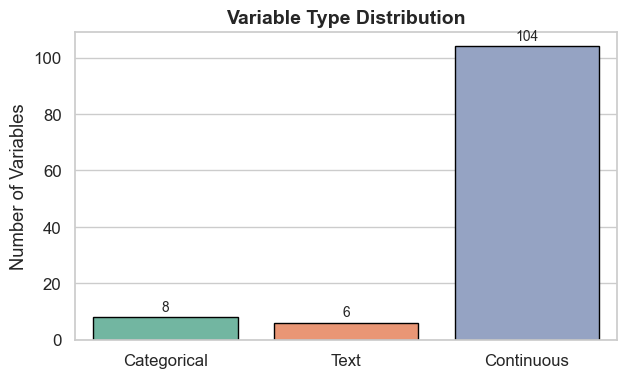

In [ ]:
var_df = pd.DataFrame(list(var_counts.items()), columns=['Variable Type', 'Count'])
sns.set(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=var_df,
    x='Variable Type',
    y='Count',
    hue='Variable Type',       # 新增 hue
    palette='Set2',
    legend=False,              # 不顯示圖例
    edgecolor='black'
)

# 顯示數值標籤
for i, v in enumerate(var_df['Count']):
    ax.text(i, v + (max(var_df['Count']) * 0.01), str(v), ha='center', va='bottom', fontsize=10)

plt.title('Variable Type Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Variables')
plt.xlabel('')
plt.savefig('/Users/mabel/Downloads/114-1/ML&FinTech/project/eda fig/variable_type_distribution.png', dpi=300, transparent=True)
plt.show()

## Missing (data drop)

In [ ]:
# show missing value ratio
missing_ratio = data.isnull().mean().sort_values(ascending=False)
print("\nMissing value ratio in each column:")
print(missing_ratio)


Missing value ratio in each column:
prvt                         0.999894
fuset                        0.999894
fopt                         0.999894
fsrct                        0.999894
iali                         0.999577
                               ...   
dummy_6400                   0.000000
dummy_6500                   0.000000
dummy_6700                   0.000000
dummy_7000                   0.000000
dummy_delist year_missing    0.000000
Length: 291, dtype: float64


In [ ]:
high_missing_cols = missing_ratio[(missing_ratio == 1.0 ) | ( missing_ratio == 0)].index
high_missing_cols = high_missing_cols.difference(["year", "gvkey"])
data_drop = data.drop(columns=high_missing_cols)

In [ ]:
features = data_drop.columns
features

Index(['gvkey', 'aco', 'acoxar', 'act', 'artfs', 'at', 'ceq', 'clt', 'dlc',
       'dltt',
       ...
       'xopr', 'xt', 'xuwti', 'fopt', 'fsrct', 'fuset', 'PERMNO',
       'delist date', 'delist year', 'year'],
      dtype='object', length=107)

In [ ]:
def build_missing_indicator(df, gvkey_col="gvkey", year_col="year"):
    df_indexed = df.set_index([gvkey_col, year_col])
    missing_df = df_indexed.isna().astype(int).reset_index()
    return missing_df


In [ ]:
missing_indicator = build_missing_indicator(data_drop, gvkey_col="gvkey", year_col="year")

### missing visualization

In [ ]:
import os
def plot_missing_scatter_sorted(
    missing_df, 
    gvkey_col="gvkey", 
    fyear_col="fyear", 
    group_size=100, 
    gvkey_limit=500,        # 🔹 新增：最多顯示公司數
    save_path=None, 
    show=True
):
    """
    缺失情況可視化（支持700+ features）
    - y 軸: 所有 features（依缺失率排序）
    - x 軸: gvkey (公司，每次 group_size 家)
    - 紅點: 缺失值
    - gvkey_limit: 最多顯示前 N 家公司（依 gvkey 排序）
    """
    df = missing_df.copy()
    df[gvkey_col] = df[gvkey_col].astype(int)
    
    # wide -> long
    melted = df.melt(
        id_vars=[gvkey_col, fyear_col], 
        var_name="feature", 
        value_name="missing_flag"
    )
    melted = melted[melted["missing_flag"] == 1].copy()

    years = sorted(melted[fyear_col].unique())

    for year in years:
        sub_year = melted[melted[fyear_col] == year].copy()

        # 🔹 依 gvkey 排序並選前 gvkey_limit 家
        gvkeys_all = sorted(sub_year[gvkey_col].unique())
        gvkeys_selected = gvkeys_all[:gvkey_limit]
        sub_year = sub_year[sub_year[gvkey_col].isin(gvkeys_selected)]

        # 計算每個 feature 的缺失率
        feat_order = (
            sub_year.groupby("feature")["missing_flag"]
            .mean()
            .sort_values(ascending=False)
            .index
        )
        sub_year["feature"] = pd.Categorical(
            sub_year["feature"], categories=feat_order, ordered=True
        )

        gvkeys = sorted(sub_year[gvkey_col].unique())
        n_groups = (len(gvkeys) + group_size - 1) // group_size

        for g in range(n_groups):
            gv_subset = gvkeys[g*group_size:(g+1)*group_size]
            sub = sub_year[sub_year[gvkey_col].isin(gv_subset)].copy()

            gvkey_to_idx = {k:i for i,k in enumerate(gv_subset)}
            sub.loc[:, "gv_idx"] = sub[gvkey_col].map(gvkey_to_idx)

            # 動態 figsize，適應700+ features
            width = max(12, 0.25 * len(gv_subset))
            height = max(10, 0.12 * len(feat_order))

            plt.figure(figsize=(width, height))
            plt.scatter(sub["gv_idx"], sub["feature"], s=5, c="red", alpha=0.4)

            plt.xticks(
                ticks=np.arange(len(gv_subset)), 
                labels=gv_subset, 
                rotation=90, 
                fontsize=6
            )
            plt.yticks(fontsize=6)
            plt.xlabel("gvkey (Company)")
            plt.ylabel("Feature (sorted by missingness)")
            plt.title(
                f"Missing Values - Year {year} "
                f"(Companies {g*group_size+1}–{min((g+1)*group_size, len(gvkeys))} of {gvkey_limit})"
            )
            plt.tight_layout()

            if save_path:
                os.makedirs(save_path, exist_ok=True)
                file_path = os.path.join(
                    save_path, 
                    f"missing_year_{year}_companies_{g*group_size+1}_{min((g+1)*group_size, len(gvkeys))}_of_{gvkey_limit}.png"
                )
                plt.savefig(file_path, dpi=300, bbox_inches="tight", transparent=True)

            if show:
                plt.show()
            else:
                plt.close()

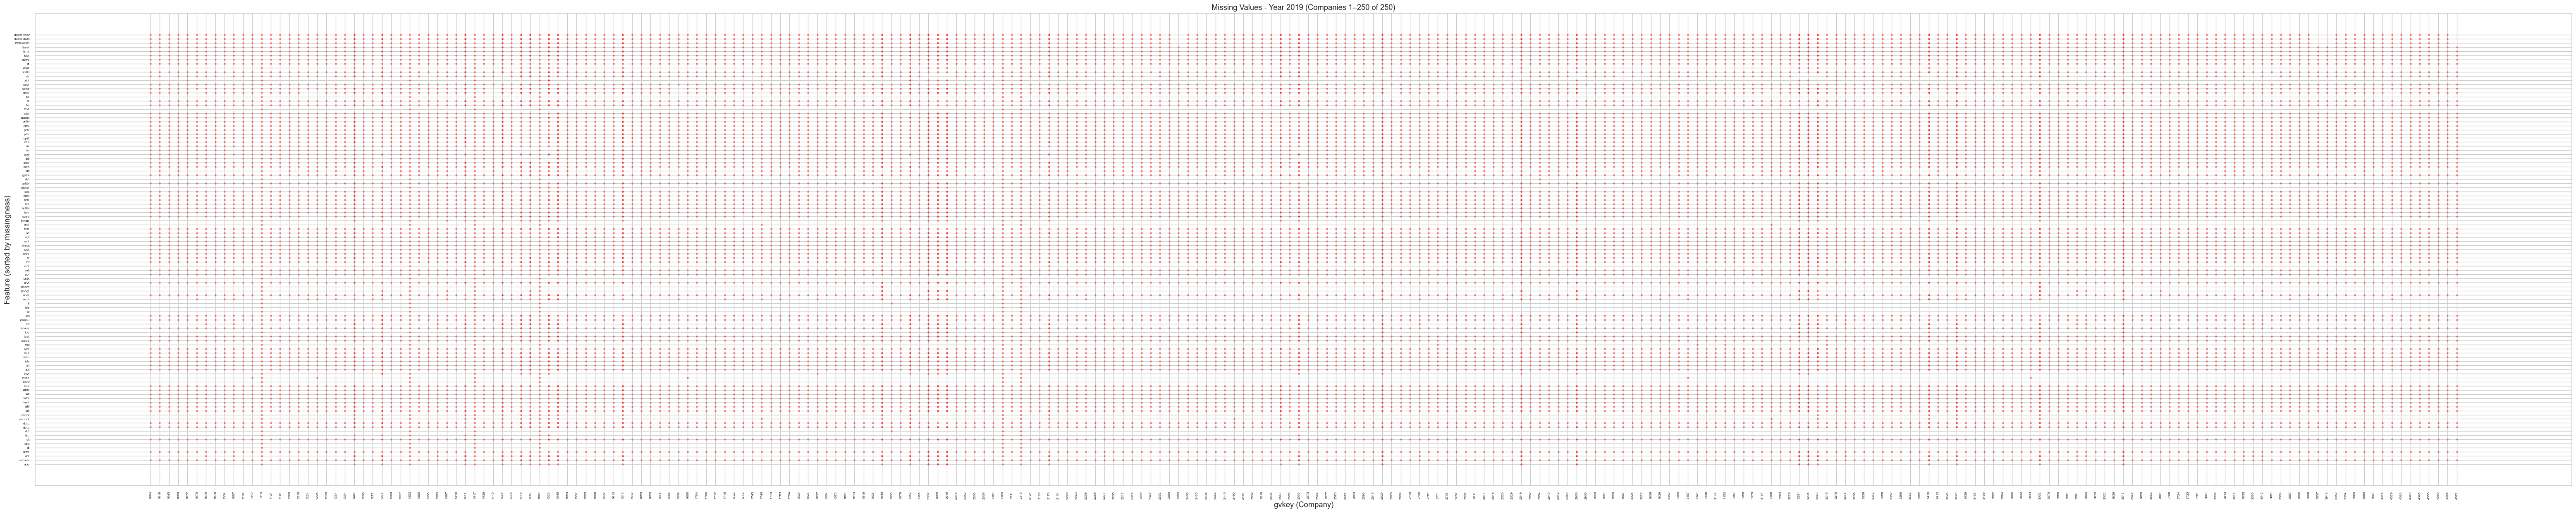

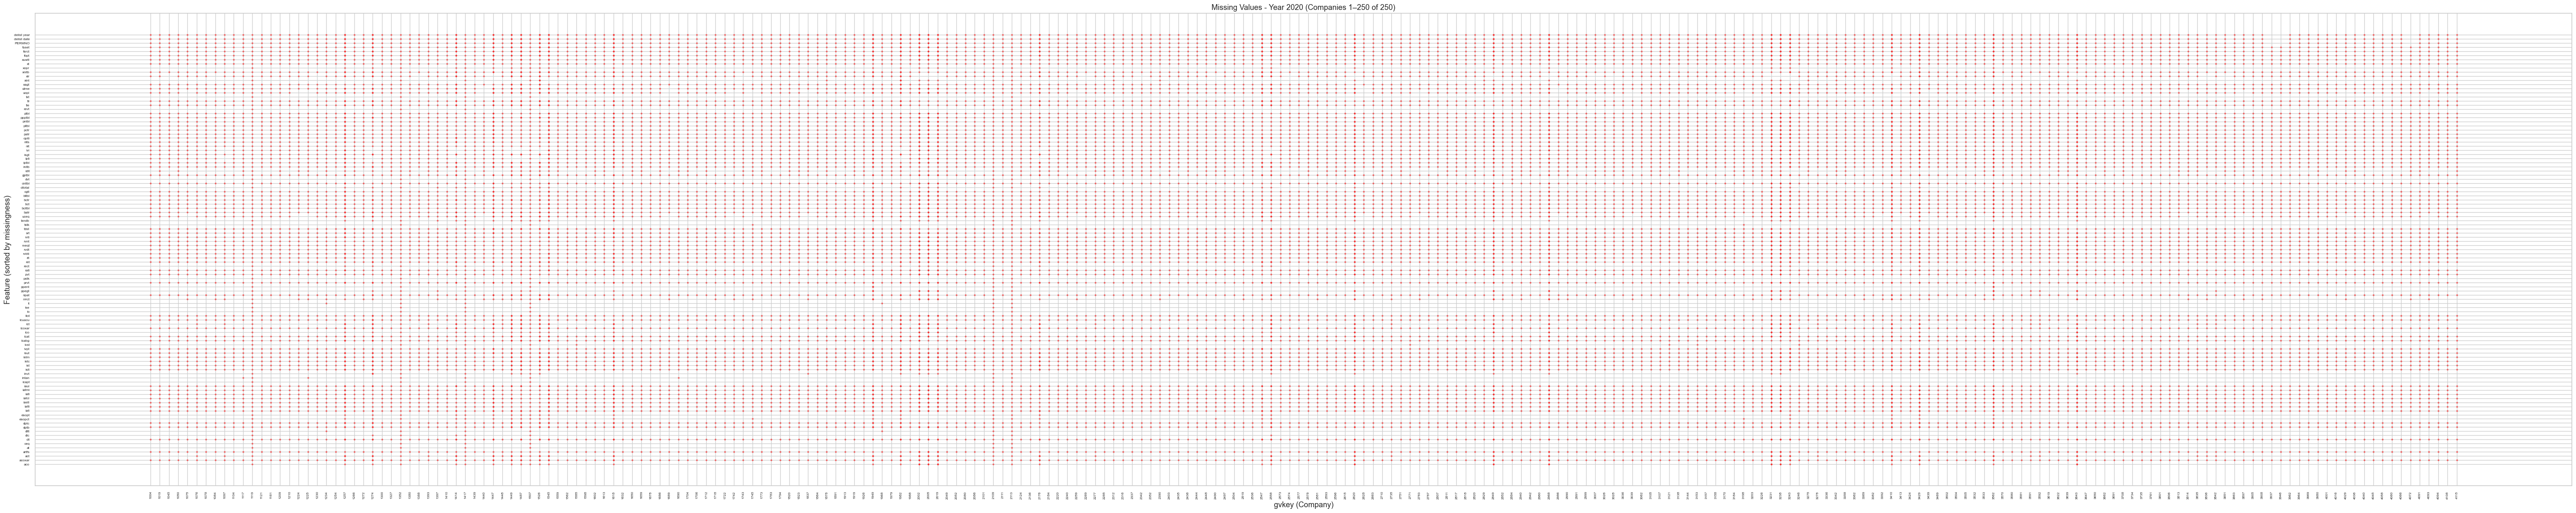

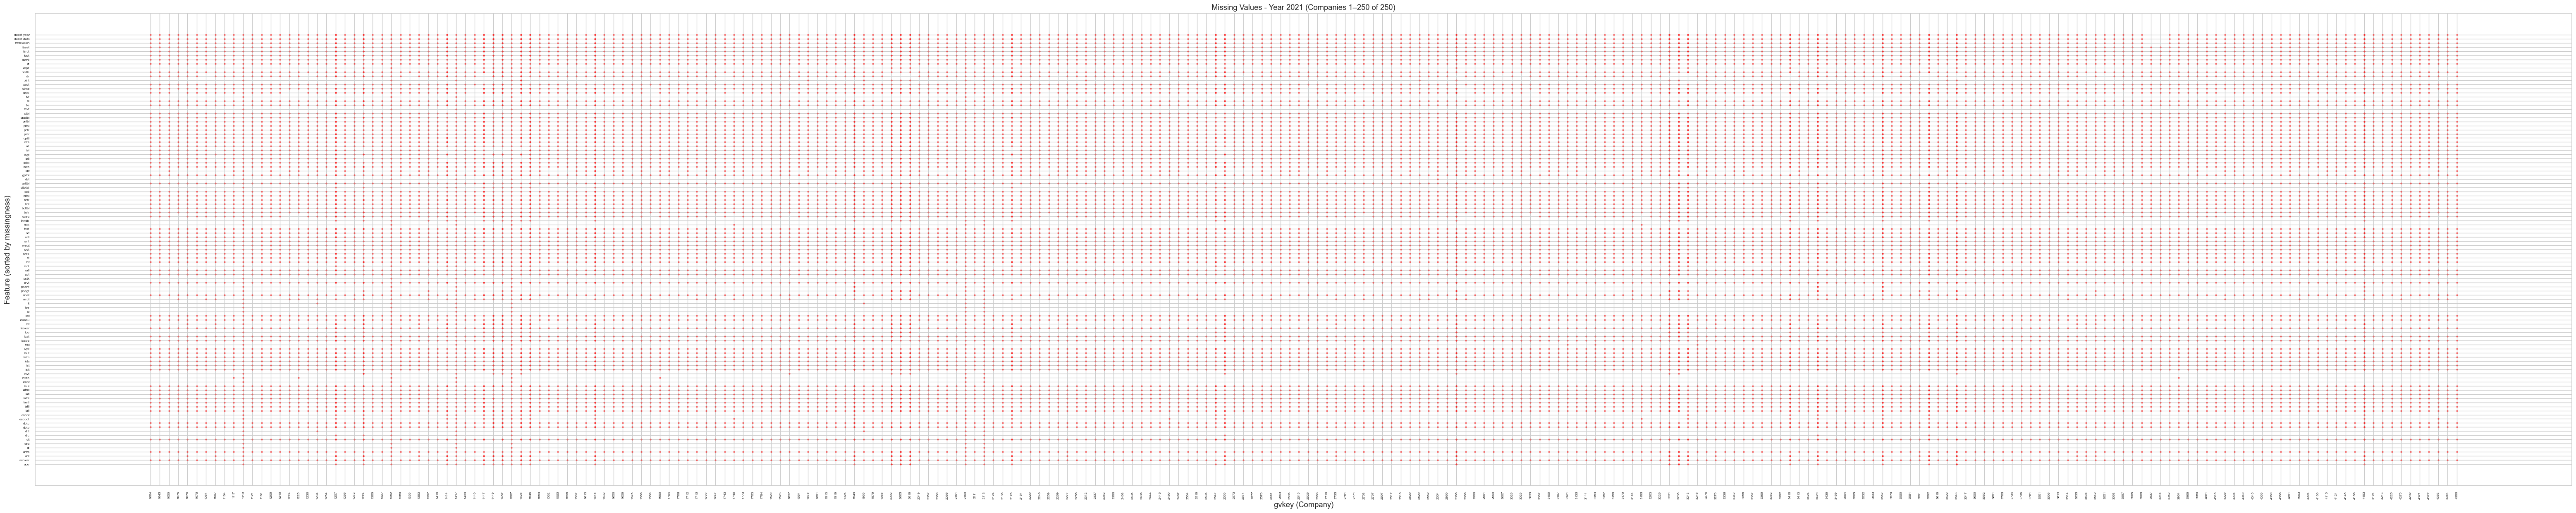

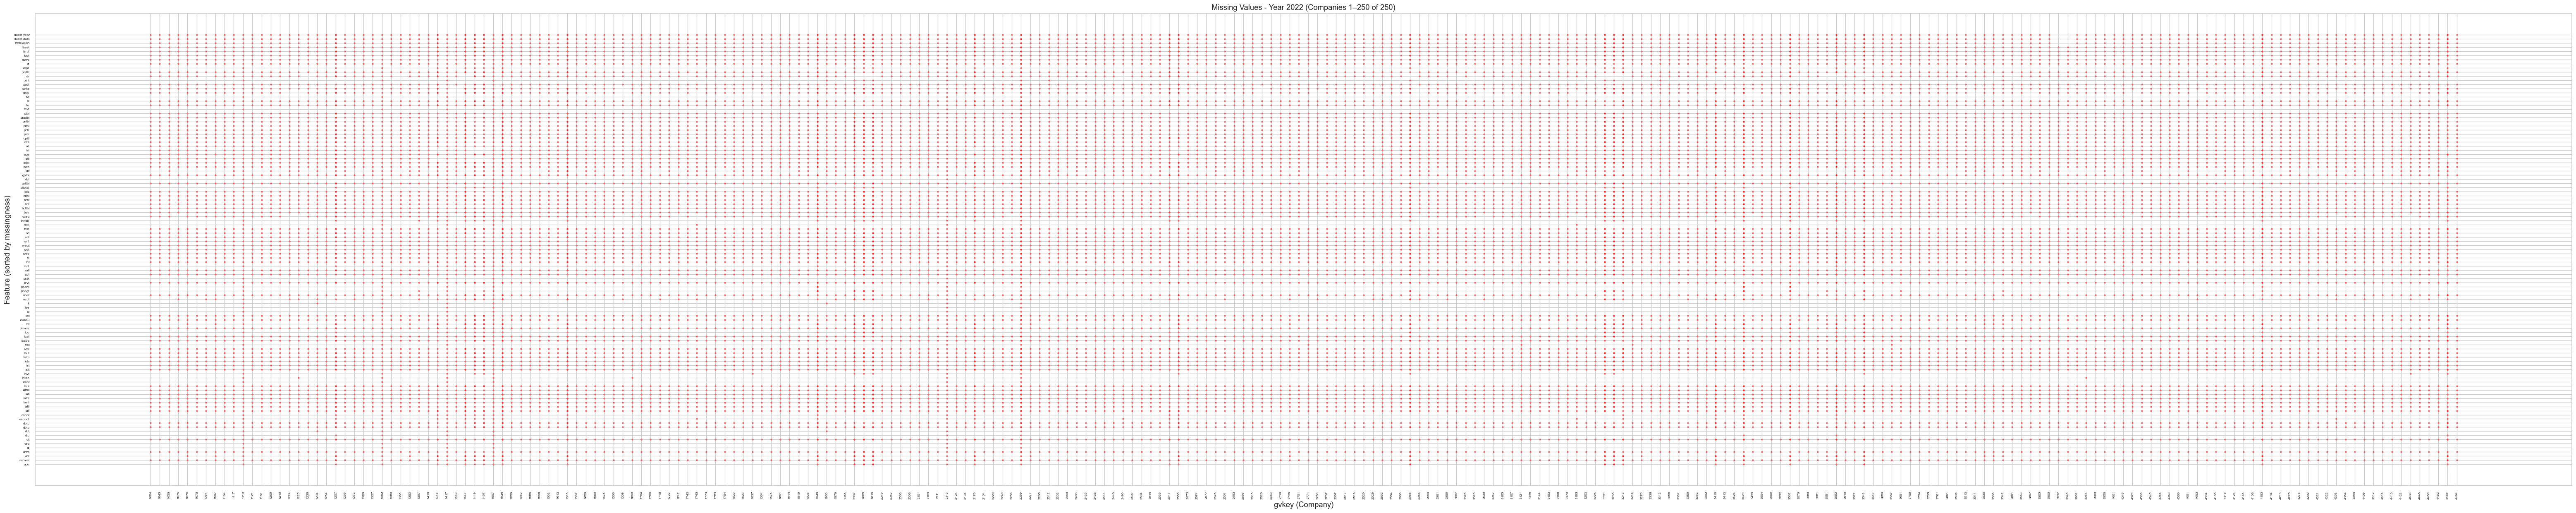

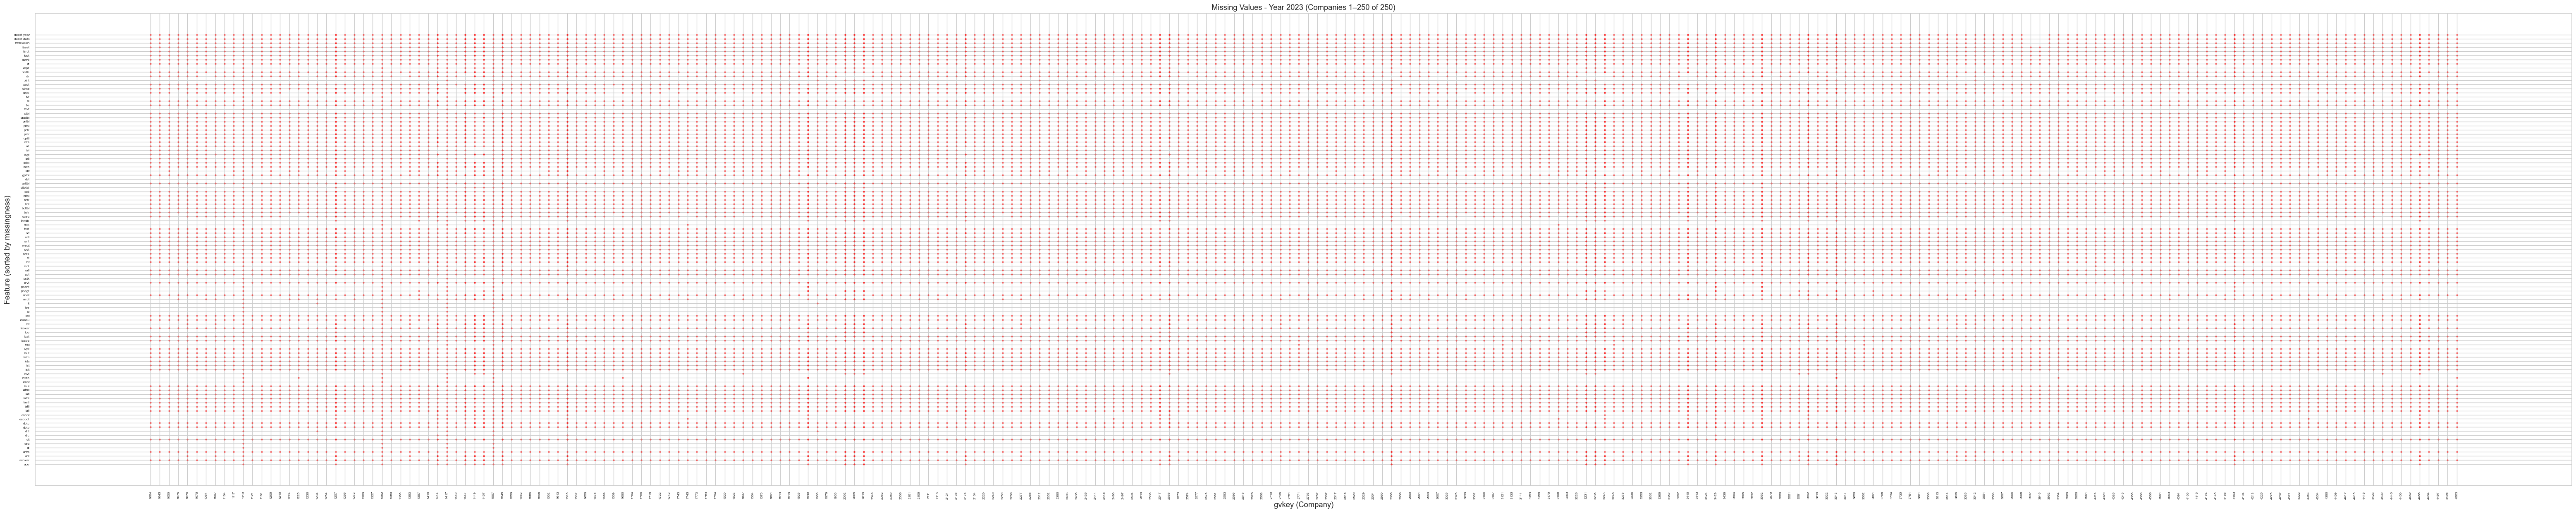

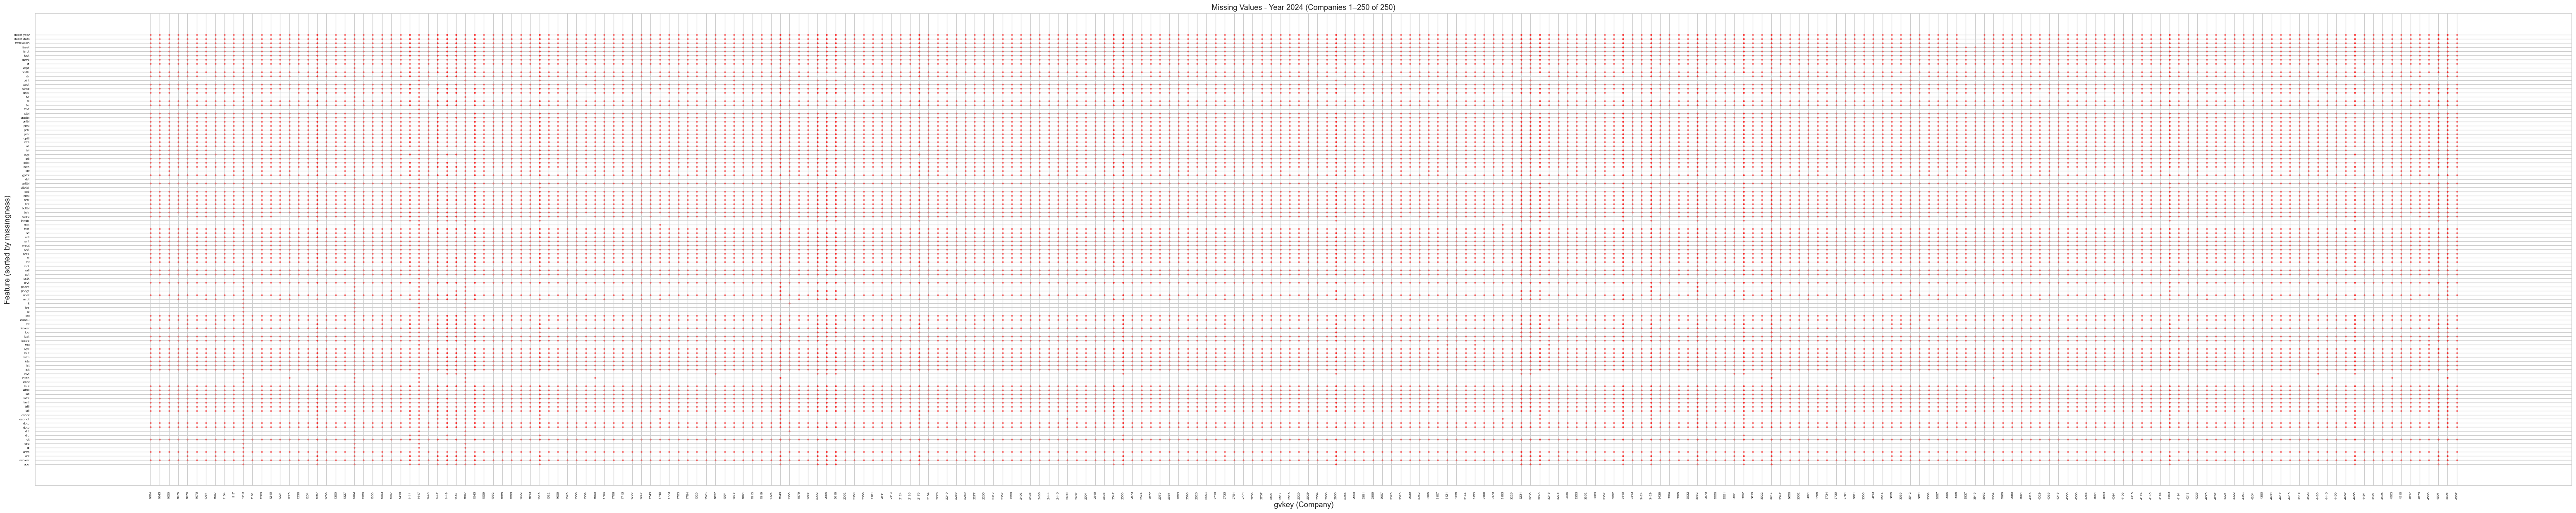

In [ ]:
plot_missing_scatter_sorted(
    missing_df=missing_indicator,
    gvkey_col="gvkey",
    fyear_col="year",
    group_size=250,
    gvkey_limit=250,
    save_path="/Users/mabel/Downloads/114-1/ML&FinTech/project/eda fig/missing scatter",
    show=True
)

## Frequency

### category

In [ ]:
select_sic = result.loc[result['dummy_delist'] == 1].copy()
select_sic['sic_ind'] = (select_sic['sic'] // 100) * 100

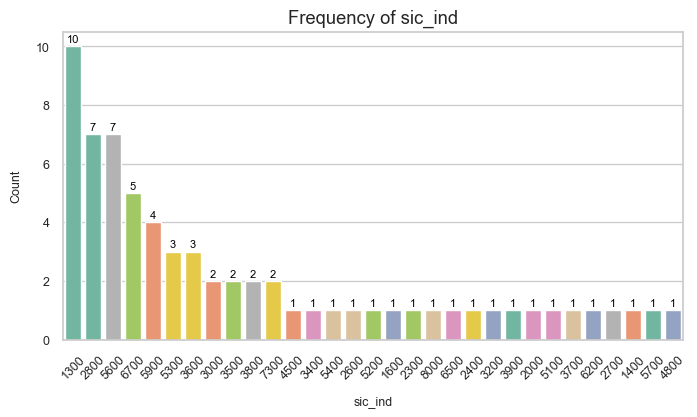

In [ ]:
categorical_vars = ['sic_ind']

for col in categorical_vars:
    plt.figure(figsize=(8,4))
    ax = sns.countplot(x=col, hue=col, data=select_sic, order=select_sic[col].value_counts().index, palette="Set2",legend=False )
    
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}",  # type: ignore
                    (p.get_x() + p.get_width() / 2., p.get_height()),  # type: ignore
                    ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),
                    textcoords='offset points')
        
        # 標題與軸標籤
    ax.set_title(f"Frequency of {col}", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(f"{col}", fontsize=9, labelpad=10)
    ax.set_ylabel("Count", fontsize=9, labelpad=10)

    # 軸刻度字體大小
    ax.tick_params(axis='x', labelsize=9, rotation=90)
    ax.tick_params(axis='y', labelsize=9)
    
    plt.title(f"Frequency of {col}")
    plt.savefig(f"/Users/mabel/Downloads/114-1/ML&FinTech/project/eda fig/{col}_frequency.png", dpi=300, bbox_inches="tight", transparent=True)
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
result['delist year'] = result['delist year'].astype(str)
vars = ['delist year', 'year'] + dummy_vars

delist_order = ["nan", "2019.0", "2020.0", "2021.0", "2022.0", "2023.0", "2024.0"]
year_order = [2019, 2020, 2021, 2022, 2023, 2024]
vars = ['delist year', 'year'] + dummy_vars

def plot_categorical_counts(df, categorical_vars, ncols=3, figsize=(18, 4)):
    """
    參數：
        df : DataFrame
        categorical_vars : list[str]  要繪製的分類欄位
        ncols : int                   每列最多子圖數
        figsize : tuple               單列高度 × 寬度
    """
    
    n = len(categorical_vars)
    nrows = (n + ncols - 1) // ncols  # 自動計算行數
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1]*nrows))
    
    # 確保 axes 可被展平成一維
    axes = axes.flatten()
    
    for idx, col in enumerate(categorical_vars):
        ax = axes[idx]
        
        # 如果是 delist year，使用固定順序
        if col == "delist year":
            order = [x for x in delist_order if x in df[col].unique()]
        elif col == "year":
            order = [x for x in year_order if x in df[col].unique()]
        else:
            order = df[col].value_counts().index


        sns.countplot(
            x=col,
            hue=col,
            data=df,
            order=order,
            palette="Set2",
            legend=False,
            ax=ax
        )

        # 標註 bar 上的數值
        for p in ax.patches:
            ax.annotate(
                f"{int(p.get_height())}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center',
                fontsize=9, color='black',
                xytext=(0,5),
                textcoords='offset points'
            )
        
        ax.set_title(f"Frequency of {col}")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    
    # 多餘 subplot 隱藏
    for j in range(idx+1, len(axes)):
        axes[j].set_visible(False)
    plt.subplots_adjust(hspace=0.6)
    plt.savefig("/Users/mabel/Downloads/114-1/ML&FinTech/project/eda fig/categorical_variables_frequency.png", dpi=300, bbox_inches="tight", transparent=True)
    plt.tight_layout()
    plt.show()

/var/folders/ff/jq6xc_c933jg460z_rffdg380000gn/T/ipykernel_99111/2655446462.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/ff/jq6xc_c933jg460z_rffdg380000gn/T/ipykernel_99111/2655446462.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/ff/jq6xc_c933jg460z_rffdg380000gn/T/ipykernel_99111/2655446462.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/ff/jq6xc_c933jg460z_rffdg380000gn/T/ipykernel_99111/2655446462.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

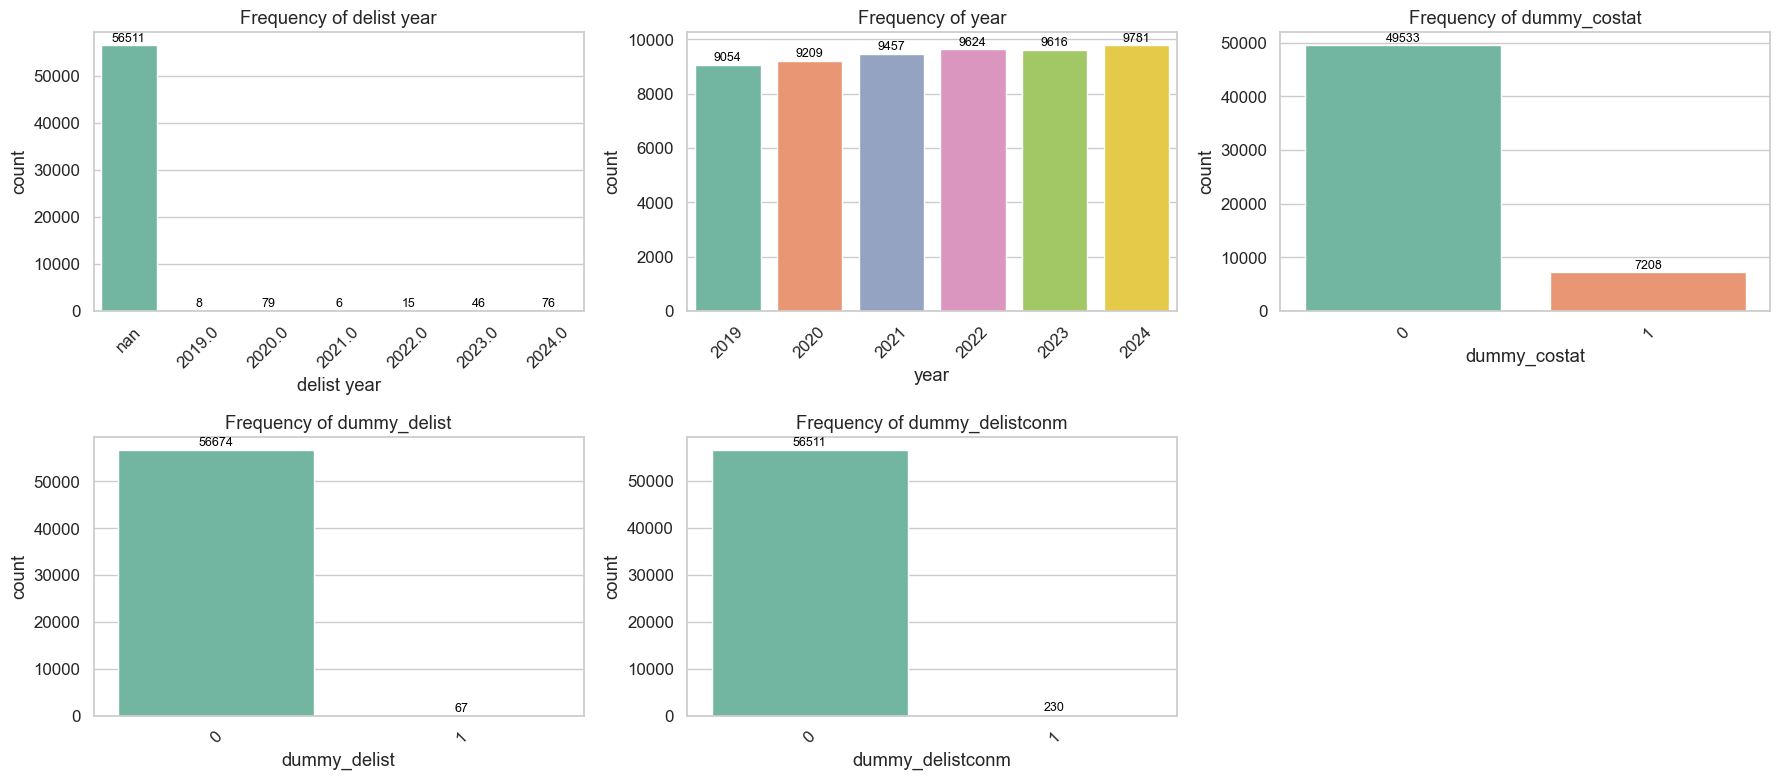

In [ ]:
plot_categorical_counts(result, vars)

### continuous description summary

In [ ]:
data_continuous_vars = merge[[col for col in numeric_all if col in numeric_vars]]

def describe_continuous(df):
    desc = df.describe().T

    desc['skewness'] = df.skew(numeric_only=True)
    desc['kurtosis'] = df.kurt(numeric_only=True)

    desc = desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max',
                 'skewness', 'kurtosis']]
    return desc

In [ ]:
continuous_var_desc = describe_continuous(data_continuous_vars)
print(round(continuous_var_desc,4))

         count       mean         std        min       25%       50%  \
lcat     280.0  7286.7906  38020.8297      0.000    0.0000    0.0000   
dvt    42636.0   156.1040    835.2809   -709.000    0.0000    0.0020   
uopi    1414.0   815.6502   1124.0984  -3221.000  177.0000  395.9000   
nits     462.0   655.1996   1288.7060  -3090.000   23.4968  144.1510   
artfs   2499.0  2334.3450  10414.7660      0.000   23.9325  104.1400   
...        ...        ...         ...        ...       ...       ...   
utme      97.0   169.6299    304.2409      9.056   20.2550   61.8950   
iaui      27.0     0.2932      1.5234      0.000    0.0000    0.0000   
xt      6294.0  3510.2531  18433.2885  -2103.493   49.2555  189.3985   
dltt   42888.0  4649.4101  87786.2399      0.000    3.6038   89.4465   
icapt  42988.0  7523.1208  91784.0651 -66283.000   73.2982  449.9040   

             75%          max  skewness   kurtosis  
lcat      0.0000   311448.000    6.2885    40.1764  
dvt      36.0000    25999.000

In [ ]:
continuous_var_desc.to_excel('/Users/mabel/Downloads/114-1/ML&FinTech/project/year_continuous variable summary.xlsx',index=1) # type: ignore

## Outlier 

In [ ]:
def check_outliers(df, threshold=3, plot=False, n_cols=5, n_show=20, dummy_keywords=["dummy"]):
    """
    用 Z-score 檢查 DataFrame 的「非 dummy」數值欄位是否有離群值，
    並輸出「前 n_show 個變數」的 boxplot（依欄位順序）。

    參數:
        df : DataFrame
        threshold : float, 判定離群的 Z-score 閾值 (預設=3)
        plot : bool, 是否畫出 boxplot (subplot 形式)
        n_cols : int, 每行 subplot 的數量
        n_show : int, 要顯示的變數數量（預設 20）
        dummy_keywords : list[str], dummy 欄位名稱中會包含的關鍵字

    回傳:
        outlier_summary : DataFrame（前 n_show 個變數的離群統計）
    """
    # 🔹 選出非 dummy 的數值欄位
    numeric_cols = [
        col for col in df.select_dtypes(include=[np.number]).columns
        if not any(key.lower() in col.lower() for key in dummy_keywords)
    ]

    # 取前 n_show 個變數
    selected_cols = numeric_cols[:n_show]

    summary_list = []

    for col in selected_cols:
        series = df[col].dropna()
        if series.std() == 0:  # 避免除以 0
            continue
        
        z_scores = stats.zscore(series)
        outlier_mask = np.abs(z_scores) > threshold
        outlier_count = outlier_mask.sum()
        outlier_pct = outlier_count / len(series) * 100
        
        summary_list.append({
            "feature": col,
            "n_obs": len(series),
            "outlier_count": outlier_count,
            "outlier_pct": round(outlier_pct, 2)
        })
    
    outlier_summary = pd.DataFrame(summary_list).set_index("feature")

    # ✅ 畫圖
    if plot and not outlier_summary.empty:
        n = len(outlier_summary)
        n_rows = math.ceil(n / n_cols)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5), dpi=150)
        axes = axes.flatten()

        for i, col in enumerate(outlier_summary.index):
            sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
            axes[i].set_title(f"{col}\nOutliers={outlier_summary.loc[col, 'outlier_count']}", fontsize=8)
            axes[i].tick_params(axis="x", labelsize=7)
            axes[i].tick_params(axis="y", labelsize=7)

        # 隱藏多餘 subplot
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()

        save_path = '/Users/mabel/Downloads/114-1/ML&FinTech/project/eda fig/outlier_boxplots.png'
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        plt.show()
    
    return outlier_summary

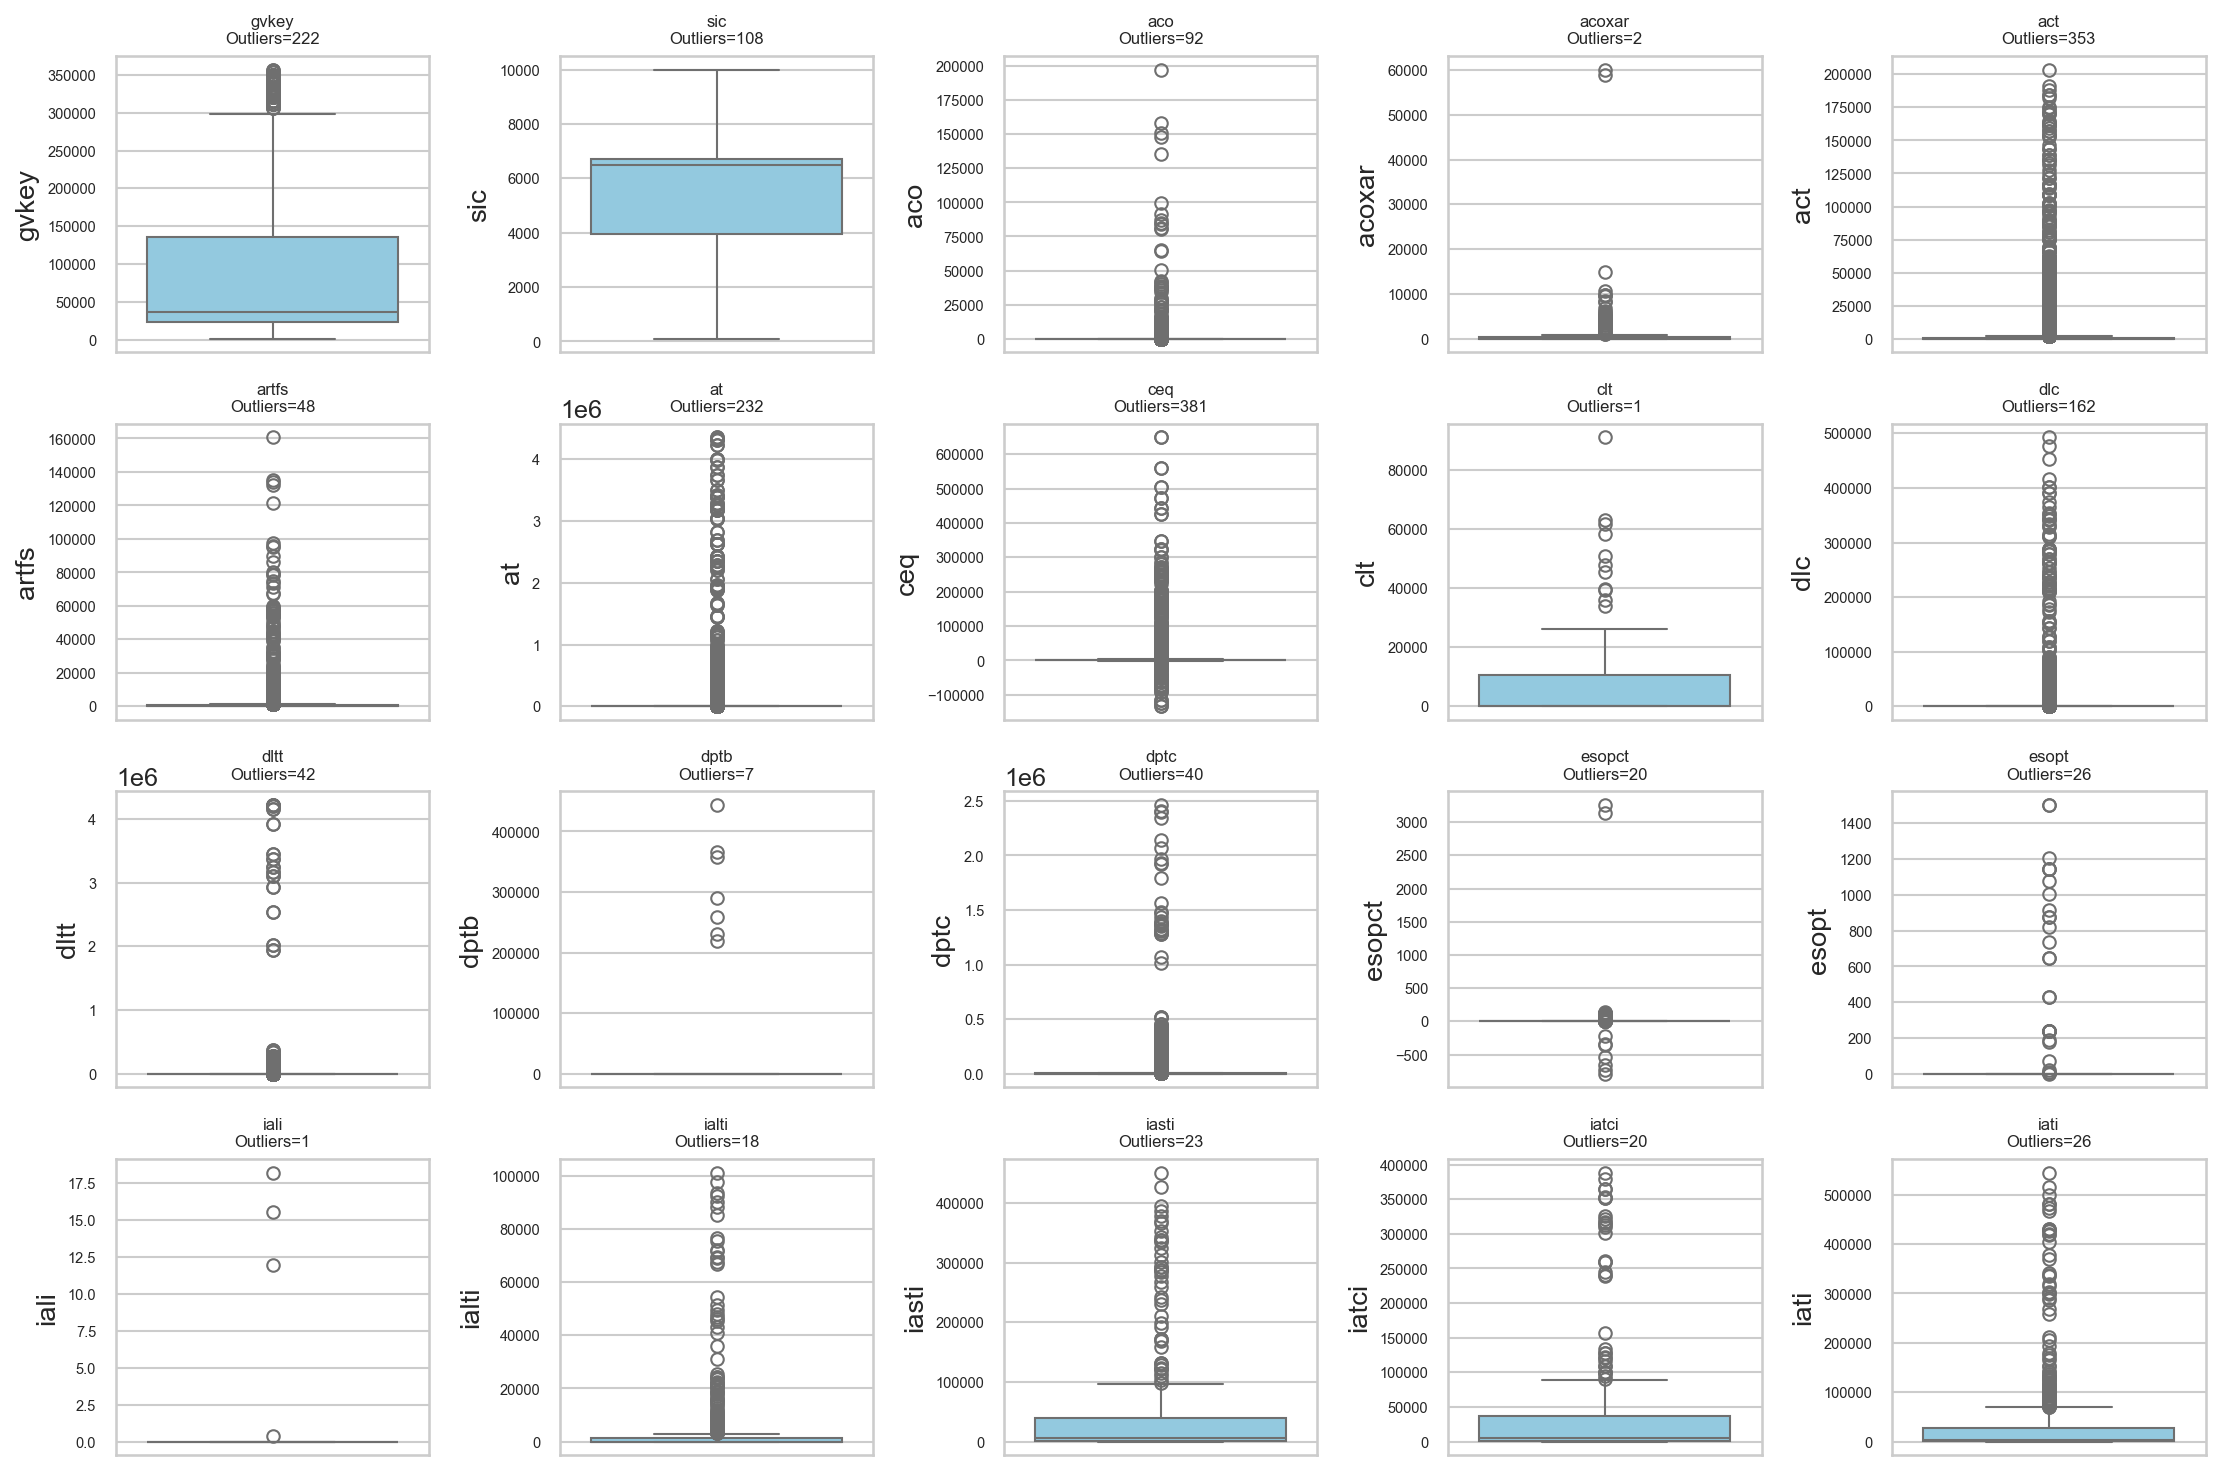

In [ ]:
outlier_first20 = check_outliers(
    merge, # 原始資料
    threshold=3,    # |Z| > 3 視為離群
    plot=True,      # 是否畫圖
    n_cols=5,       # 每行 5 張子圖
    n_show=20,      # 前 20 個變數
    dummy_keywords=["dummy"]  # 排除 dummy 欄位
)

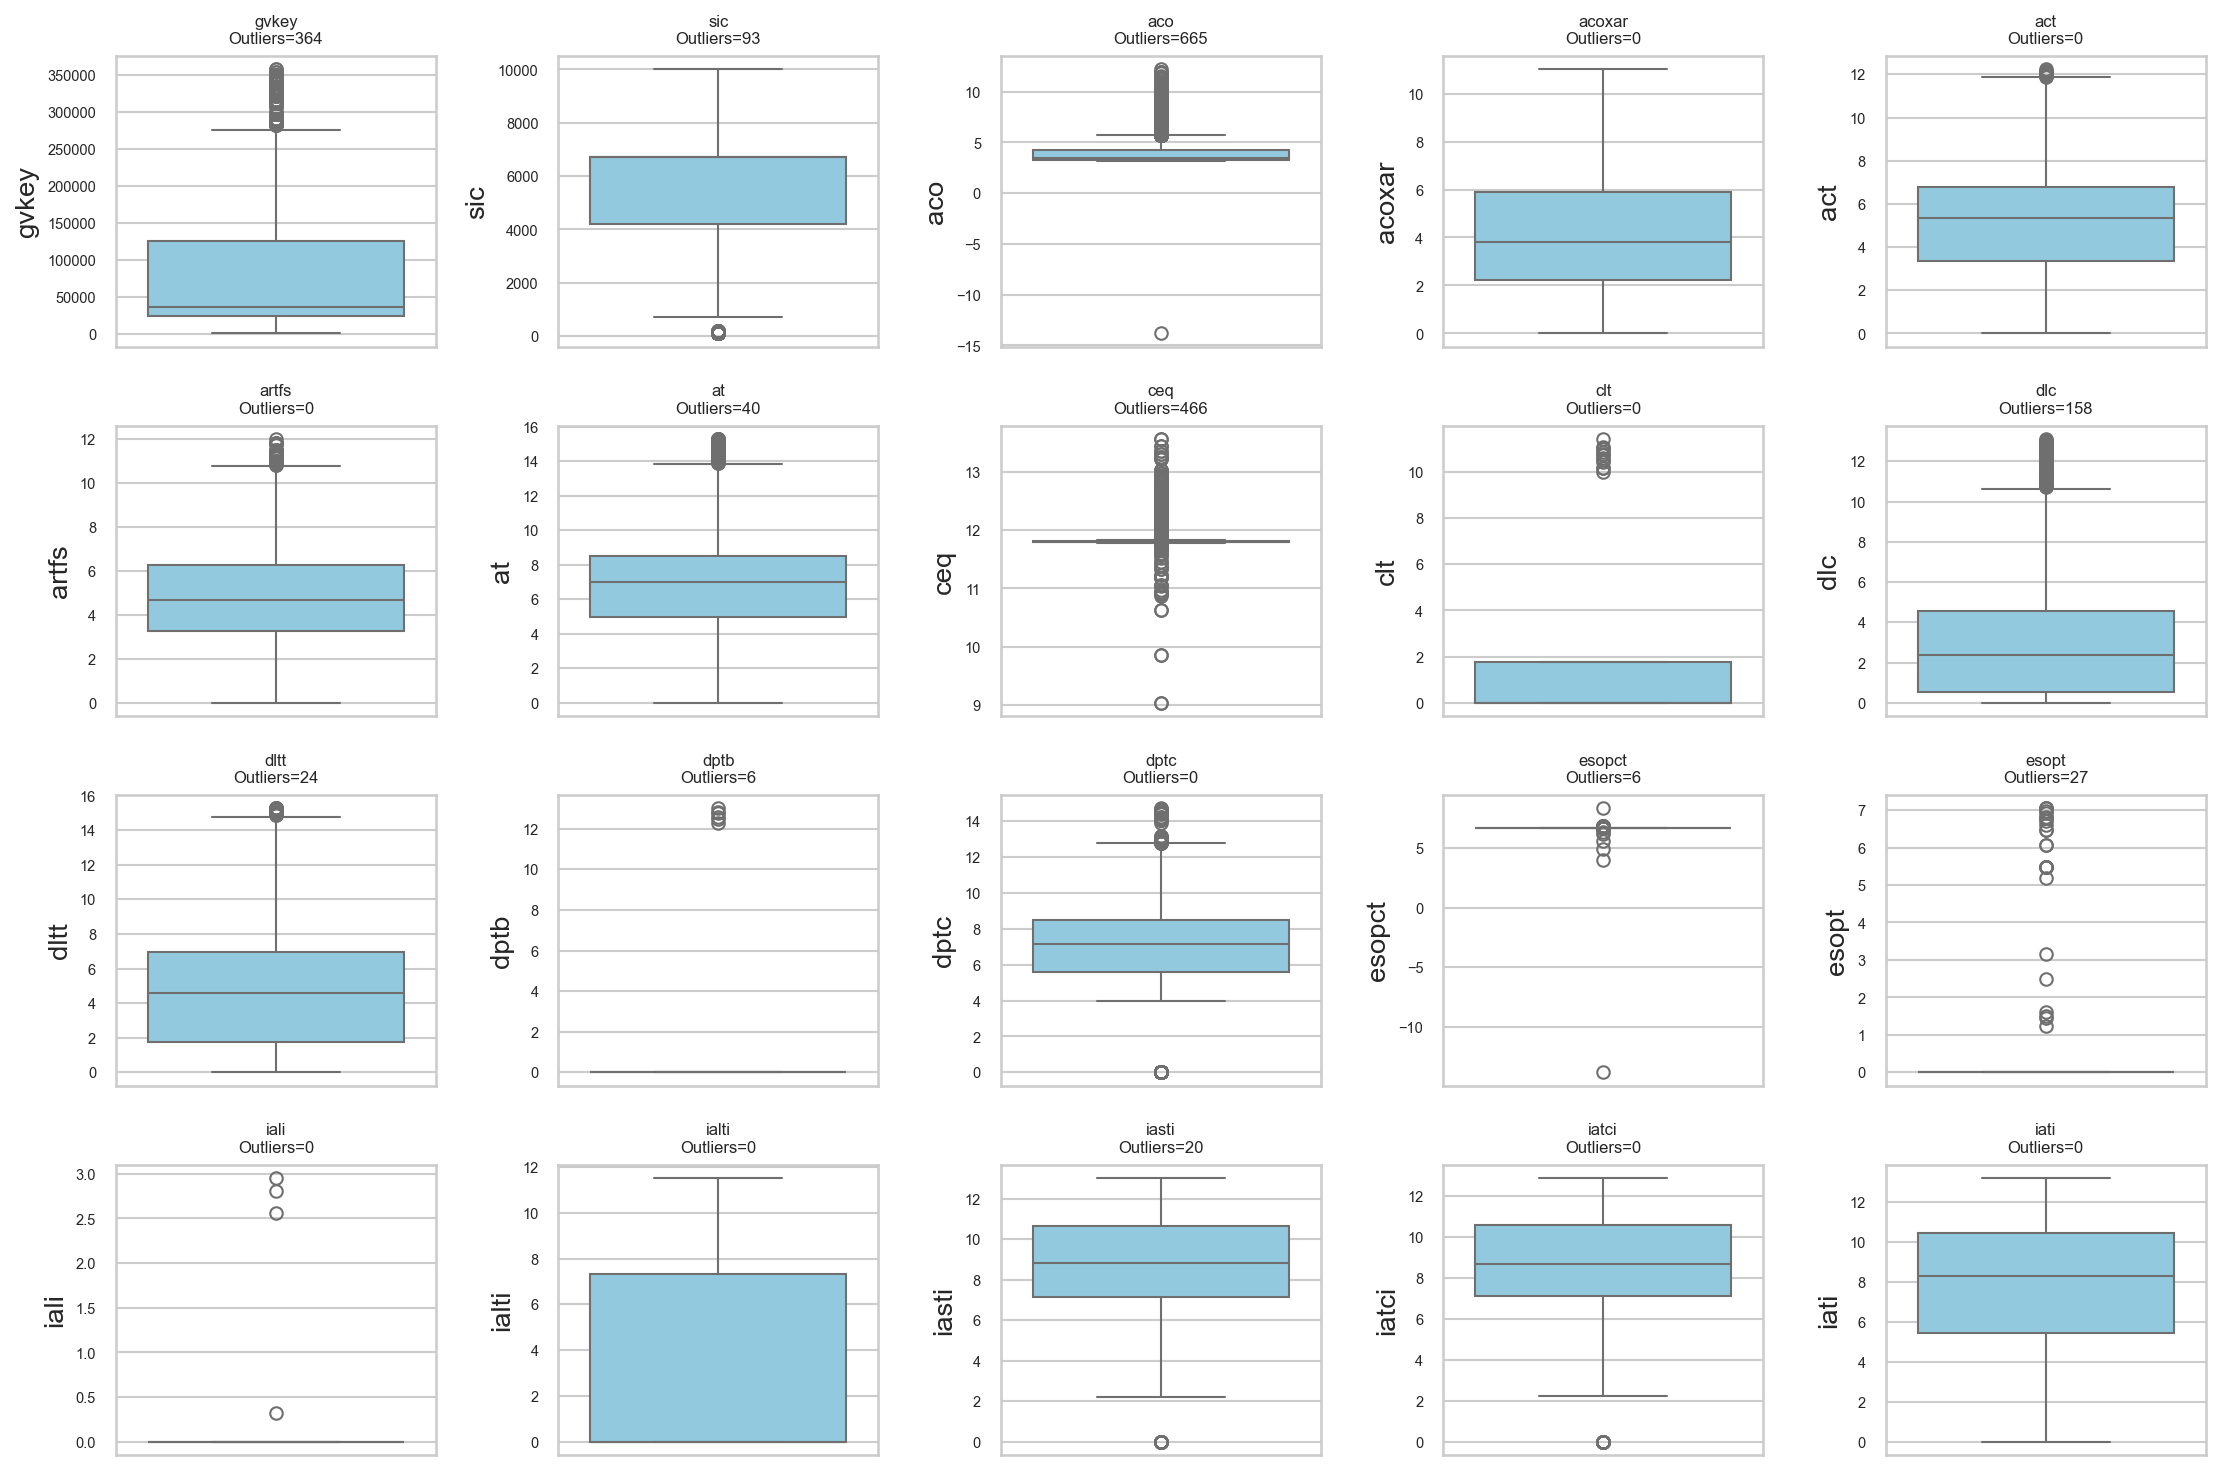

In [ ]:
outlier_first20 = check_outliers(
    result, # 原始資料
    threshold=3,    # |Z| > 3 視為離群
    plot=True,      # 是否畫圖
    n_cols=5,       # 每行 5 張子圖
    n_show=20,      # 前 20 個變數
    dummy_keywords=["dummy"]  # 排除 dummy 欄位
)

## Pairplot

In [ ]:
pair_var = ['at','lt','lo','dvt','revt','nits','dummy_delist','dummy_delistconm','dummy_costat']

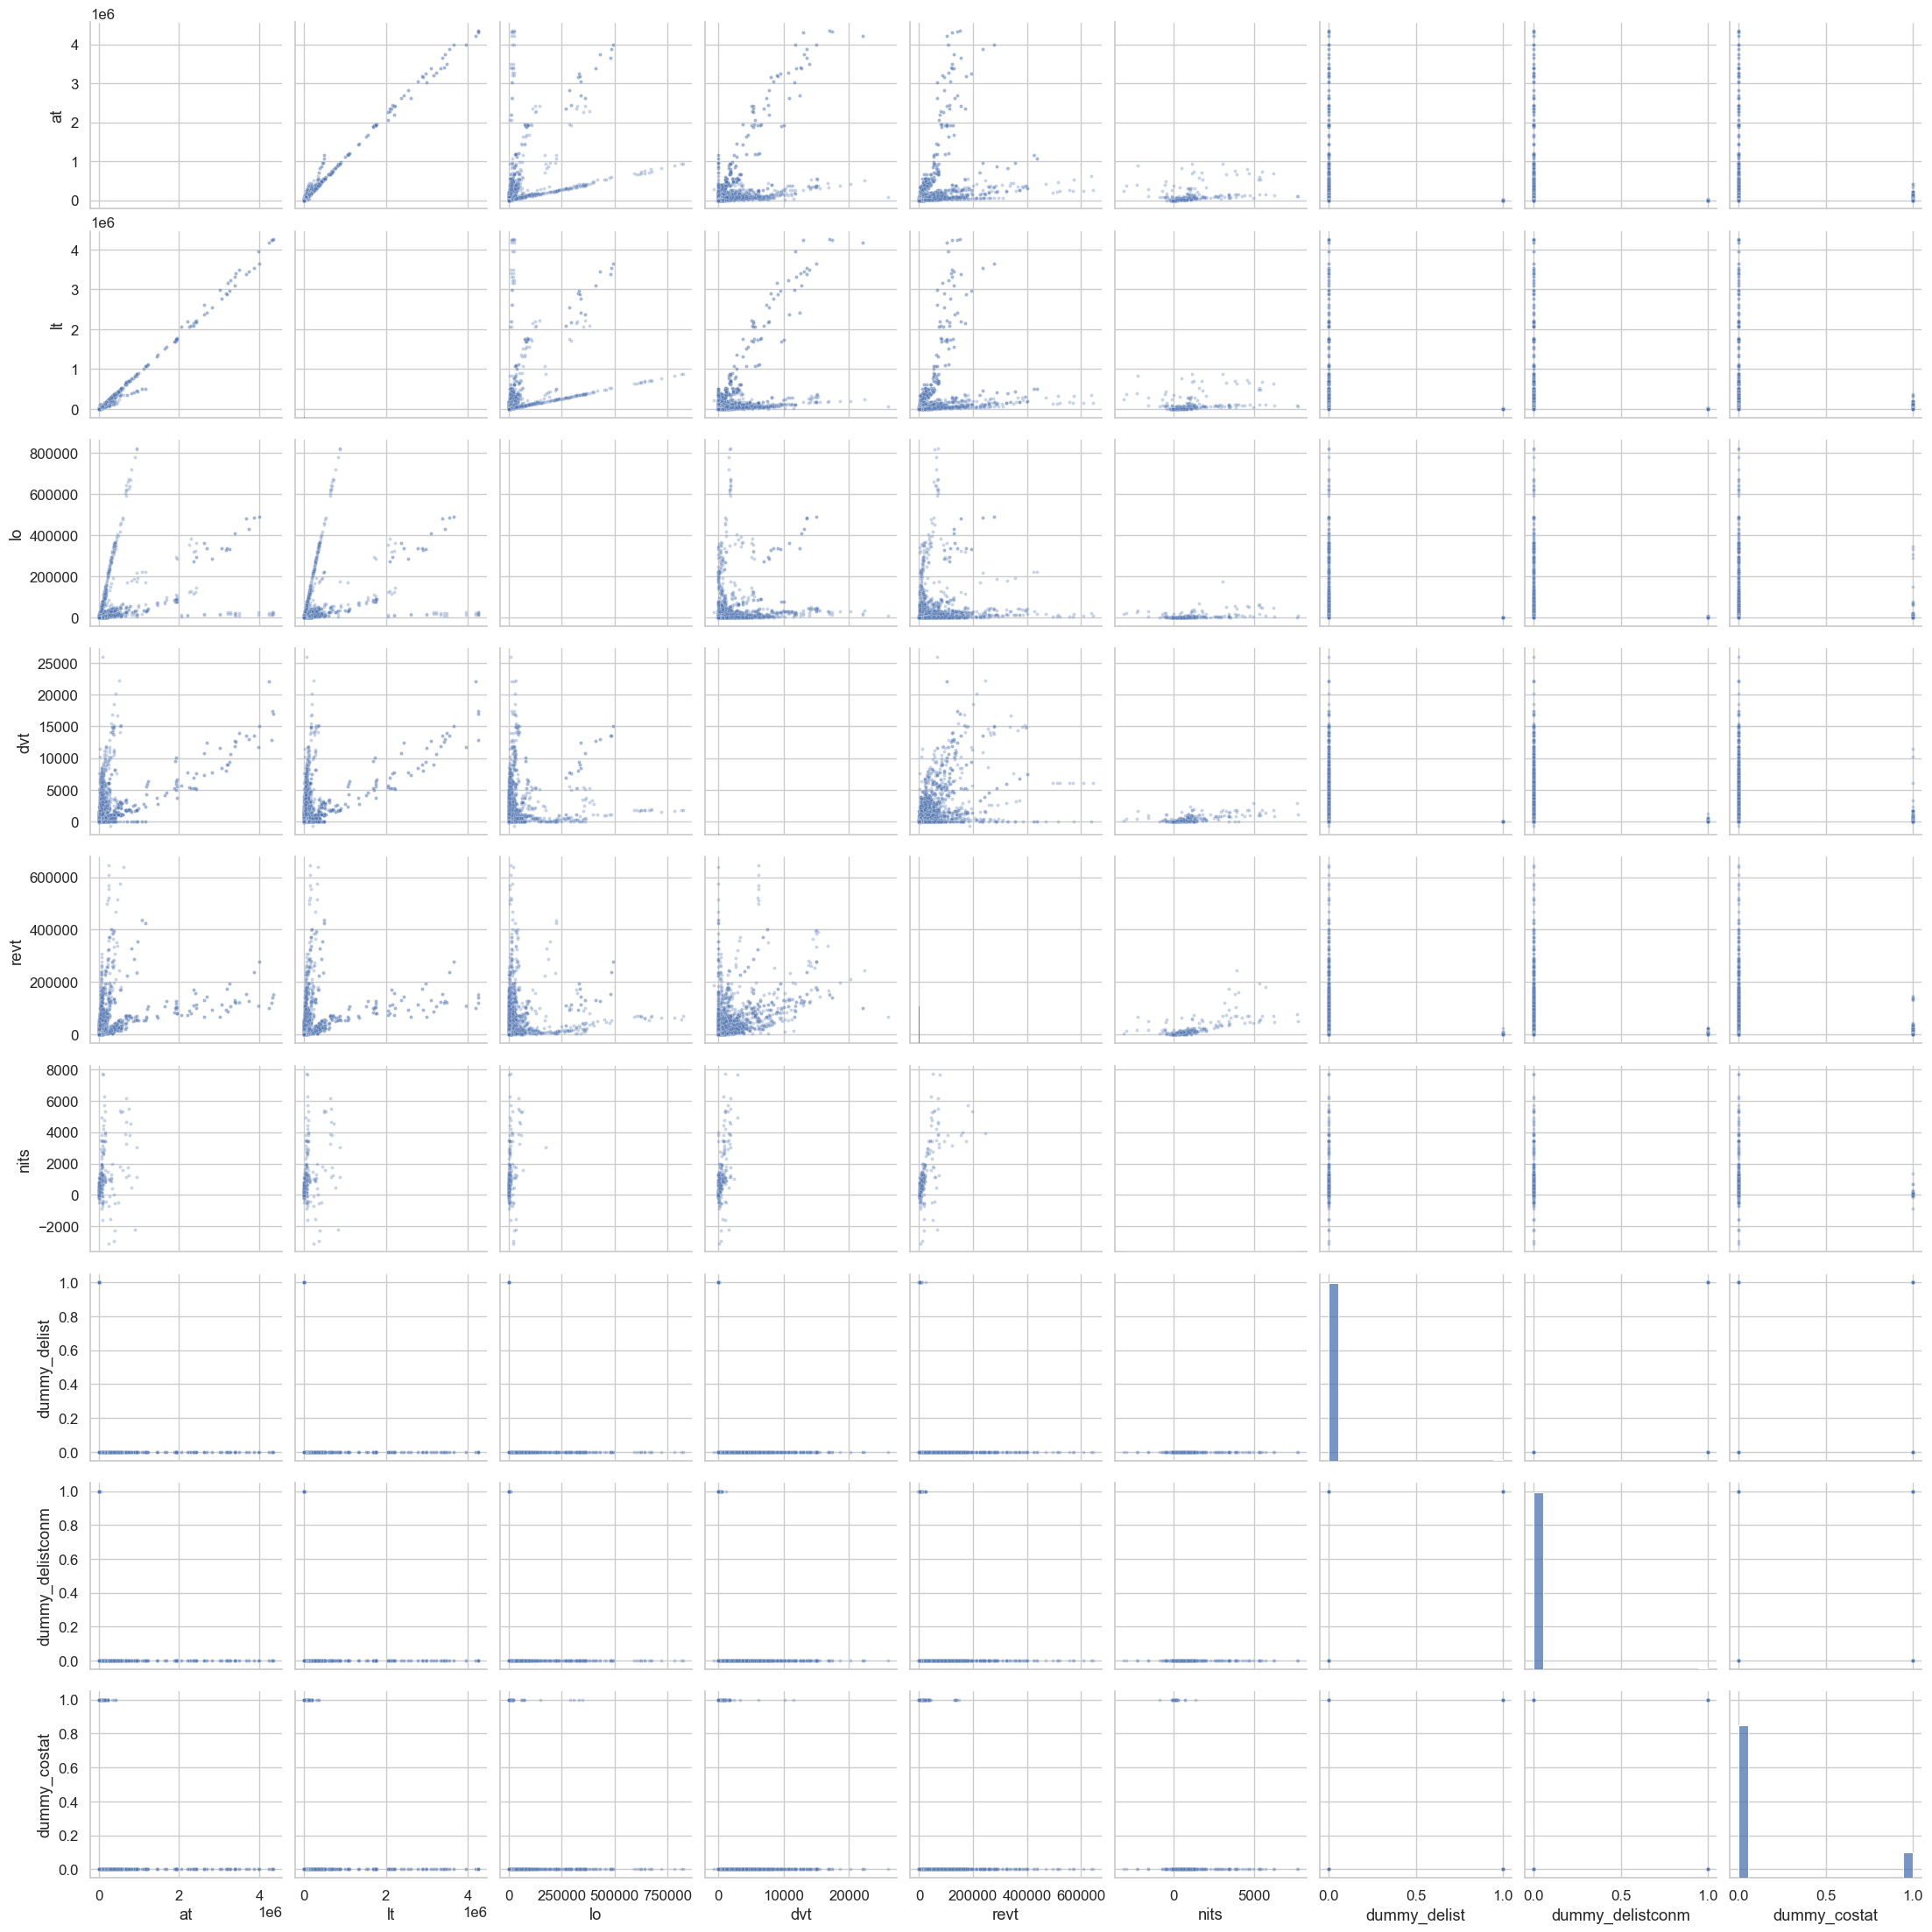

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.pairplot(merge[pair_var], diag_kind='hist', plot_kws={'alpha':0.3, 's':8})
plt.show()
plt.savefig('/Users/mabel/Downloads/114-1/ML&FinTech/project/eda fig/pairplot.png', dpi=300, bbox_inches="tight", transparent=True)

correlation

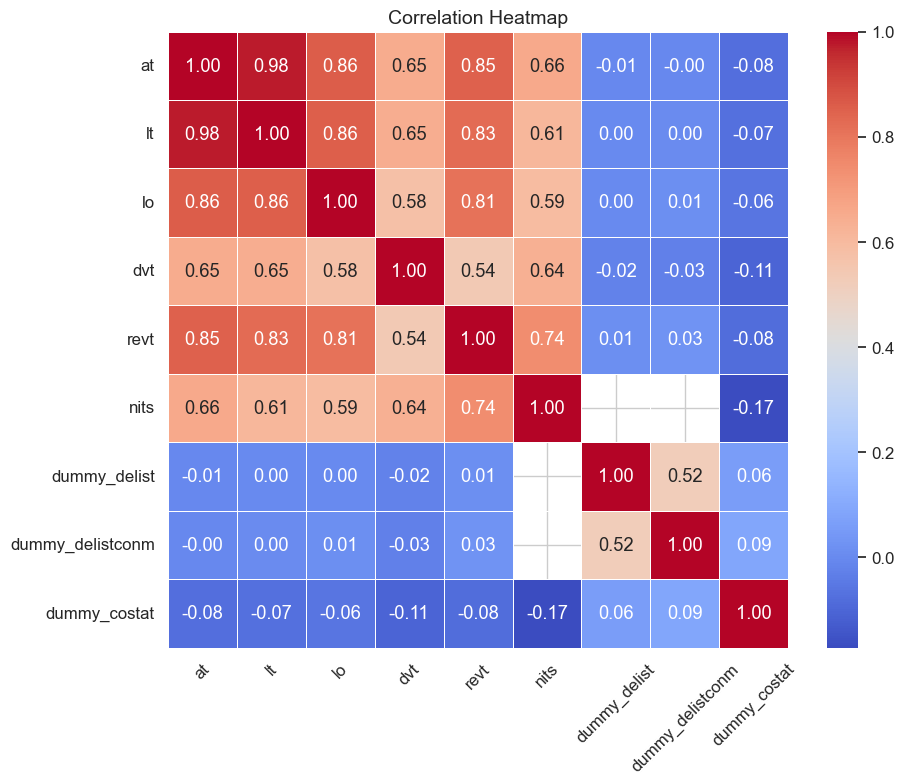

In [ ]:
corr = merge[pair_var].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            annot=True,          # 顯示數字
            fmt=".2f",           # 小數位數
            cmap="coolwarm",     # 顏色方案
            linewidths=0.5)      # 網格線
plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.savefig('/Users/mabel/Downloads/114-1/ML&FinTech/project/eda fig/correlation_heatmap.png', dpi=300, bbox_inches="tight", transparent=True)
plt.show()

PCA

In [ ]:
# 對所有連續變數進行PCA
pca_data = result[numeric_vars].copy()
pca_data = pca_data.fillna(pca_data.median())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_data)



from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # 保留95% variation
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.14204594 0.09042423 0.05779772 0.04146483 0.0325126  0.02874289
 0.02844181 0.0262474  0.02302898 0.02192884 0.01963389 0.01925995
 0.01782135 0.01605228 0.0148699  0.01407333 0.01303889 0.01283911
 0.01234593 0.01156916 0.01131292 0.01087763 0.01056759 0.01046496
 0.01010932 0.00981881 0.00976401 0.00964486 0.0096068  0.00951617
 0.00944901 0.00934973 0.00928576 0.00914566 0.00911026 0.00881105
 0.00867981 0.00849334 0.00809873 0.00759979 0.00736525 0.00723342
 0.00680289 0.0065822  0.00639504 0.00627333 0.00603029 0.00577147
 0.00554958 0.00551139 0.00533511 0.00504914 0.00498946 0.00474665
 0.00446634 0.00445274 0.00434272 0.00401942 0.00375955 0.00369336
 0.00359527 0.00349597 0.0033945 ]


In [ ]:
pca_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_cols, index=result.index)


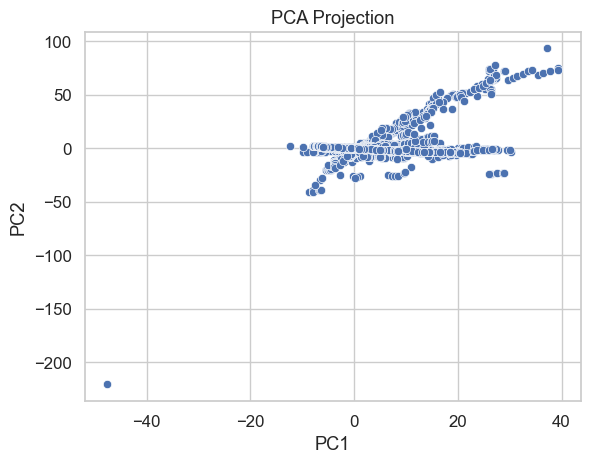

In [ ]:
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'])
plt.title("PCA Projection")
plt.show()